<a href="https://colab.research.google.com/github/cdiegor/OtimizacaoCombinatoria/blob/main/BB_2D_Manual.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Branch-and-Bound Manual (2 variáveis) — Notebook Didático
**Data:** 2025-11-24

Este caderno executa **Branch-and-Bound (B\&B)** manualmente para um problema 2D de **programação inteira**:

\begin{aligned}
max \ & z = 3x_1 + 2x_2 & \\
\text{sujeito a} & & \\
& 5x_1 + 3x_2 &\le 30,\\
& x_1 + 2x_2 &\le 10,\\
& 4x_1 + 5x_2 &\le 30,\\
& x_1 \ge 0,\quad x_2 \ge 0,\\
& x_1, x_2 \in \mathbb{Z}.
\end{aligned}


**Políticas do B\&B:**
- **Ramificação:** variável **mais fracionária** (maior distância ao inteiro mais próximo).
- **Seleção do nó:** **DFS** (sempre o mais recente gerado).

Inclui funções para **visualizar** o conjunto viável (relaxado) e a solução ótima.


In [ ]:

import math
from itertools import combinations
from typing import List, Tuple, Optional, Dict

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (7, 5)
plt.rcParams["axes.grid"] = True


## Definição do problema base

In [ ]:

c = np.array([3.0, 2.0])
A = np.array([[5.0, 3.0],[1.0, 2.0],[4.0, 5.0]], dtype=float)
b = np.array([30.0, 10.0, 30.0], dtype=float)
base_bounds = {"x1_min": 0.0, "x1_max": float("inf"), "x2_min": 0.0, "x2_max": float("inf")}

def augment_constraints_with_bounds(A: np.ndarray, b: np.ndarray, bounds: Dict[str, float]) -> Tuple[np.ndarray, np.ndarray]:
    rows, rhs = [], []
    if not math.isinf(bounds.get("x1_min", -float("inf"))) and bounds["x1_min"] != -float("inf"):
        rows.append([-1.0, 0.0]); rhs.append(-bounds["x1_min"])
    if not math.isinf(bounds.get("x1_max", float("inf"))):
        rows.append([1.0, 0.0]); rhs.append(bounds["x1_max"])
    if not math.isinf(bounds.get("x2_min", -float("inf"))) and bounds["x2_min"] != -float("inf"):
        rows.append([0.0, -1.0]); rhs.append(-bounds["x2_min"])
    if not math.isinf(bounds.get("x2_max", float("inf"))):
        rows.append([0.0, 1.0]); rhs.append(bounds["x2_max"])
    if rows:
        A_aug = np.vstack([A, np.array(rows)])
        b_aug = np.concatenate([b, np.array(rhs)])
    else:
        A_aug, b_aug = A.copy(), b.copy()
    return A_aug, b_aug


## Solução de LP (relaxação) em 2D por vértices

In [ ]:

def intersection_point(a1,b1,a2,b2):
    Aeq = np.vstack([a1, a2])
    beq = np.array([b1, b2], dtype=float)
    if abs(np.linalg.det(Aeq)) < 1e-12:
        return None
    return np.linalg.solve(Aeq, beq)

def is_feasible_point(x, A, b, tol=1e-9):
    return np.all(A @ x <= b + tol)

def enumerate_vertices(A, b):
    verts = []
    m = A.shape[0]
    for i,j in combinations(range(m), 2):
        p = intersection_point(A[i,:], b[i], A[j,:], b[j])
        if p is None:
            continue
        if is_feasible_point(p, A, b):
            verts.append(p)
    uniq = []
    for v in verts:
        if not any(np.linalg.norm(v-u) < 1e-8 for u in uniq):
            uniq.append(v)
    return uniq

def solve_lp_relaxation(c, A, b):
    verts = enumerate_vertices(A,b)
    if not verts:
        test = np.array([0.0,0.0])
        if is_feasible_point(test, A, b):
            return "optimal", test, float(c @ test)
        else:
            return "infeasible", None, None
    best_x, best_z = None, -float("inf")
    for v in verts:
        z = float(c @ v)
        if z > best_z + 1e-12:
            best_z, best_x = z, v
    return "optimal", best_x, best_z


## Visualização do conjunto viável e solução ótima (relaxada)

In [ ]:

def order_polygon_points(points):
    if not points: return points
    pts = np.array(points)
    center = pts.mean(axis=0)
    ang = np.arctan2(pts[:,1]-center[1], pts[:,0]-center[0])
    idx = np.argsort(ang)
    return [pts[i] for i in idx]

def plot_feasible_with_optimum(
    A, b, c,
    title="Região factível e ótimo",
    xstar=None,
    save_path=None,
    show_gradient=True,        # <- novo
    grad_origin="origin",      # "auto" | "origin" | "centroid"
    arrow_scale=0.25,          # fração do tamanho do gráfico
    bounds=None
):


    verts = enumerate_vertices(A,b)
    poly = order_polygon_points(verts)


    plt.figure()
    if len(poly) >= 3:
        xs = [p[0] for p in poly] + [poly[0][0]]
        ys = [p[1] for p in poly] + [poly[0][1]]
        plt.plot(xs, ys, marker="o")
        plt.fill(xs, ys, alpha=0.2)
    else:
        for p in verts:
            plt.plot([p[0]],[p[1]], marker="o", zorder=1)


    # --- seta do gradiente (direção de crescimento do objetivo) ---
    if show_gradient:
        ax = plt.gca()
        ax.set_aspect('equal')
        ax.set_xlim(0, 7)
        ax.set_ylim(0, 6)
        xmin, xmax = ax.get_xlim()
        ymin, ymax = ax.get_ylim()
        rx = max(1e-9, xmax - xmin)
        ry = max(1e-9, ymax - ymin)

        # origem da seta
        if grad_origin == "origin":
            x0, y0 = 0.0, 0.0
        elif grad_origin == "centroid" and len(verts) > 0:
            cent = np.array(verts).mean(axis=0)
            x0, y0 = float(cent[0]), float(cent[1])
        else:  # "auto": canto inferior com uma pequena margem
            x0 = xmin + 0.05 * rx
            y0 = ymin + 0.05 * ry

        # direção do gradiente (normalizada) e escala no gráfico
        c_vec = np.array(c, dtype=float)
        norm = np.linalg.norm(c_vec)
        if norm > 0:
            u = c_vec / norm
            # comprimentos proporcionais ao tamanho do plot
            L = arrow_scale * np.sqrt(rx**2 + ry**2)
            dx, dy = u[0]*L, u[1]*L

            # seta (o usuário pediu vermelho)
            plt.arrow(
                x0, y0, dx, dy,
                head_width=0.05*max(rx, ry),
                head_length=0.08*max(rx, ry),
                length_includes_head=True,
                fc='red', ec='red'
            )

    if bounds is not None:
        if np.isfinite(bounds.get("x1_max", np.inf)):
            plt.axvline(bounds["x1_max"], linestyle='dashed')   # não especificar cor
        if np.isfinite(bounds.get("x1_min", -np.inf)):
            plt.axvline(bounds["x1_min"], linestyle='dashed')
        if np.isfinite(bounds.get("x2_max", np.inf)):
            plt.axhline(bounds["x2_max"], linestyle='dashed')
        if np.isfinite(bounds.get("x2_min", -np.inf)):
            plt.axhline(bounds["x2_min"], linestyle='dashed')

    if xstar is not None:
        plt.scatter([xstar[0]],[xstar[1]], marker='x', facecolor='red', zorder=2)



    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
    plt.show()




Relaxação raiz: optimal x* = [4.61538462 2.30769231] z* = 18.46153846153846


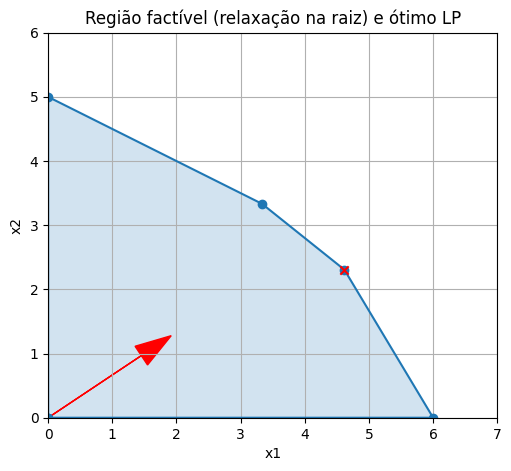

In [ ]:
# Mostrando o problema e solução linear

A0, b0 = augment_constraints_with_bounds(A,b, base_bounds)
status, xrel, zrel = solve_lp_relaxation(c, A0, b0)
print("Relaxação raiz:", status, "x* =", xrel, "z* =", zrel)
plot_feasible_with_optimum(A0, b0, c, "Região factível (relaxação na raiz) e ótimo LP", xrel if status=="optimal" else None)

## Motor Branch-and-Bound (DFS; variável mais fracionária)

In [ ]:

class Node:
    def __init__(self, bounds, depth=0, name=""):
        self.bounds = dict(bounds)
        self.depth = depth
        self.name = name
        self.status = None
        self.xrel = None
        self.zrel = None

def most_fractional_var(x, names=("x1","x2")):
    cand = []
    for i,nm in enumerate(names):
        d = abs(x[i] - round(x[i]))
        if d > 1e-9:
            cand.append((d, nm, x[i]))
    if not cand:
        return None
    cand.sort(reverse=True)
    return cand[0][1]

def branch_children(bounds, var, value):
    floor_v = math.floor(value)
    ceil_v = math.ceil(value)
    left = dict(bounds); left[f"{var}_max"] = min(bounds.get(f"{var}_max", float("inf")), float(floor_v))
    right = dict(bounds); right[f"{var}_min"] = max(bounds.get(f"{var}_min", -float("inf")), float(ceil_v))
    return left, right

def is_integral(x, tol=1e-9):
    return all(abs(x[i] - round(x[i])) <= tol for i in range(len(x)))

def bb_solve(c, A, b, base_bounds, plot_nodes=True):
    incumbent_x, incumbent_z = None, -float("inf")
    stack = [Node(base_bounds, depth=0, name="raiz")]
    trace = []
    while stack:
        node = stack.pop()
        A_aug, b_aug = augment_constraints_with_bounds(A,b,node.bounds)
        status, xrel, zrel = solve_lp_relaxation(c, A_aug, b_aug)
        node.status, node.xrel, node.zrel = status, xrel, zrel
        trace.append((node.name, node.depth, status, xrel, zrel, dict(node.bounds)))
        print(f"[{node.name}] depth={node.depth} status={status} xrel={xrel} zrel={zrel}")
        if plot_nodes and status=="optimal" and xrel is not None:
            plot_feasible_with_optimum(A_aug, b_aug, c, f"Nó {node.name} (LP)", xrel,bounds=node.bounds)
        if status != "optimal" or xrel is None:
            continue
        if zrel <= incumbent_z + 1e-9:
            print(f"  -> Poda por bound: zrel={zrel} <= incumbente={incumbent_z}")
            continue
        if is_integral(xrel):
            zint = float(c @ xrel)
            if zint > incumbent_z + 1e-9:
                incumbent_z, incumbent_x = zint, xrel.copy()
                print(f"  -> Incumbente atualizado: x={incumbent_x}, z={incumbent_z}")
            continue
        var = most_fractional_var(xrel, names=("x1","x2"))
        val = xrel[0] if var=="x1" else xrel[1]
        left_bounds, right_bounds = branch_children(node.bounds, var, val)
        stack.append(Node(right_bounds, depth=node.depth+1, name=f"{node.name}R"))
        stack.append(Node(left_bounds,  depth=node.depth+1, name=f"{node.name}L"))
    return incumbent_x, incumbent_z, trace


[raiz] depth=0 status=optimal xrel=[4.61538462 2.30769231] zrel=18.46153846153846


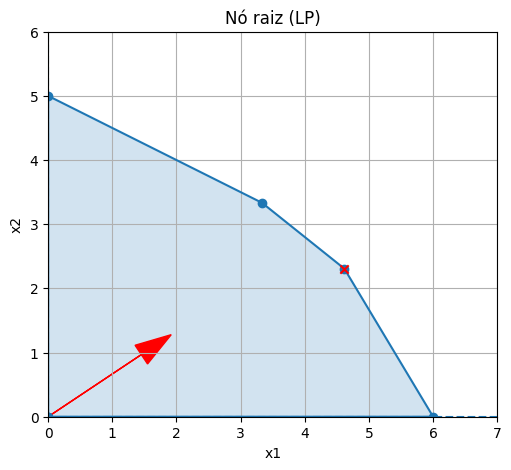

[raizL] depth=1 status=optimal xrel=[4.  2.8] zrel=17.6


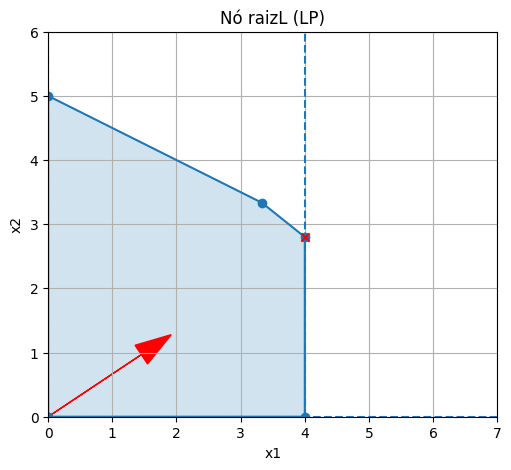

[raizLL] depth=2 status=optimal xrel=[4. 2.] zrel=16.0


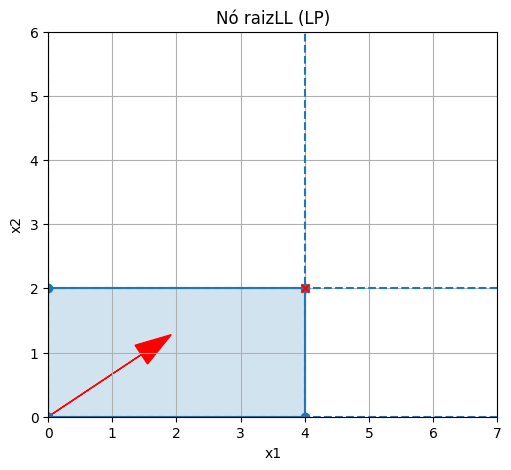

  -> Incumbente atualizado: x=[4. 2.], z=16.0
[raizLR] depth=2 status=optimal xrel=[3.75 3.  ] zrel=17.25


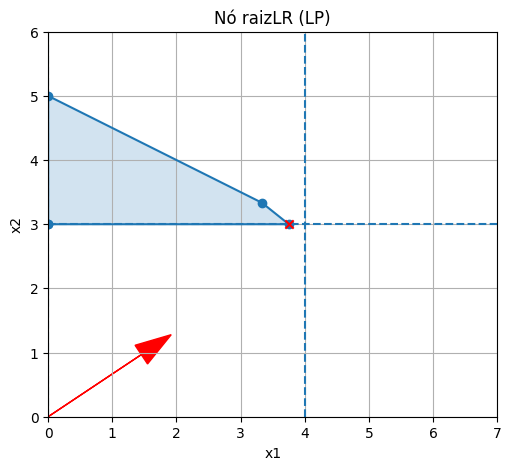

[raizLRL] depth=3 status=optimal xrel=[3.  3.5] zrel=16.0


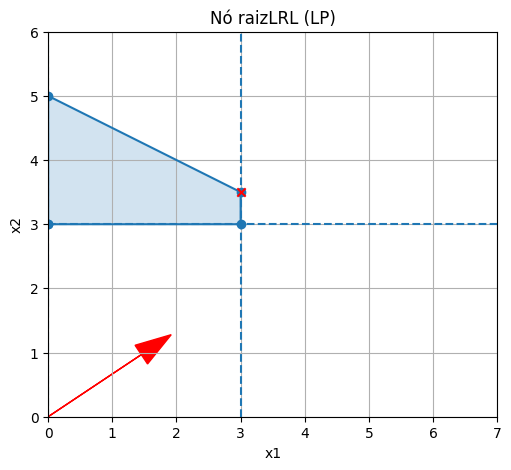

  -> Poda por bound: zrel=16.0 <= incumbente=16.0
[raizLRR] depth=3 status=infeasible xrel=None zrel=None
[raizR] depth=1 status=optimal xrel=[5.         1.66666667] zrel=18.333333333333332


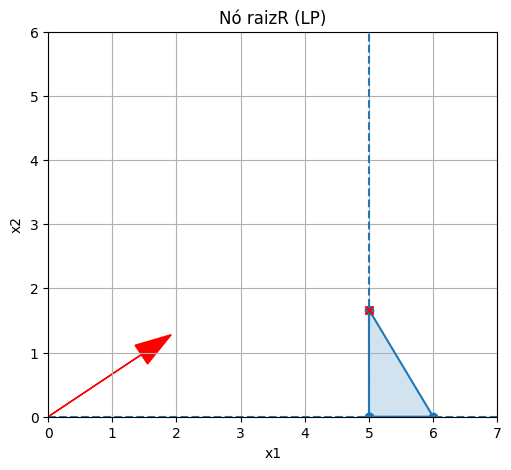

[raizRL] depth=2 status=optimal xrel=[5.4 1. ] zrel=18.200000000000003


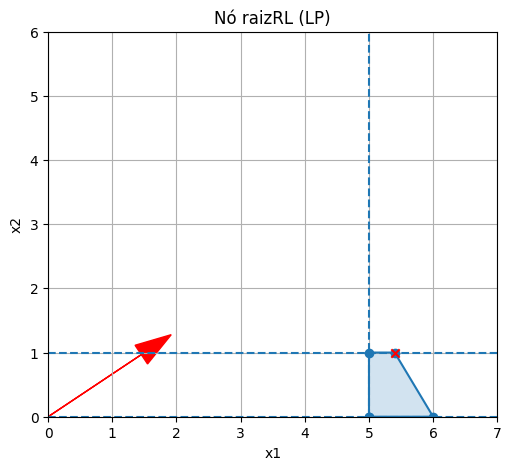

[raizRLL] depth=3 status=optimal xrel=[5. 1.] zrel=17.0


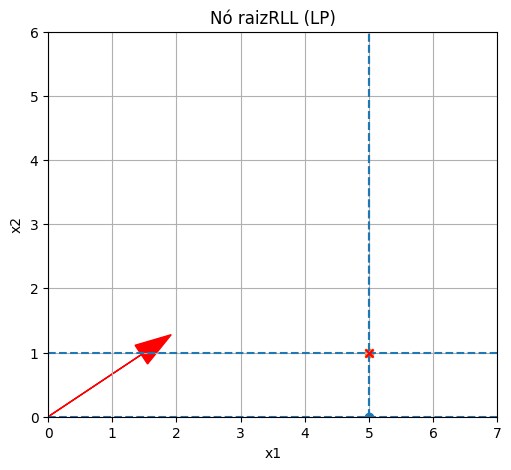

  -> Incumbente atualizado: x=[5. 1.], z=17.0
[raizRLR] depth=3 status=optimal xrel=[6. 0.] zrel=18.0


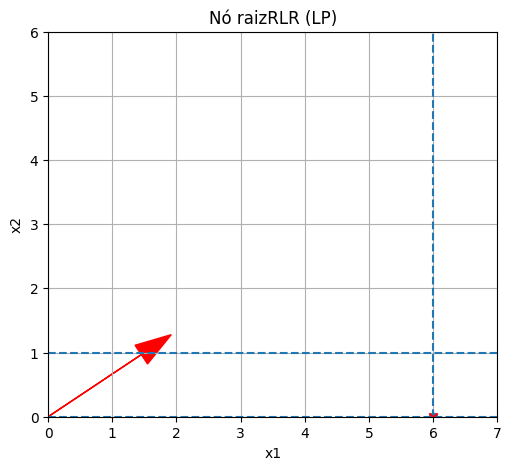

  -> Incumbente atualizado: x=[6. 0.], z=18.0
[raizRR] depth=2 status=infeasible xrel=None zrel=None

Melhor solução inteira encontrada:
x* = [6. 0.]   z* = 18.0


In [ ]:
#Execução do Branch-and-Bound
x_inc, z_inc, trace = bb_solve(c, A, b, base_bounds, plot_nodes=True)
print("\nMelhor solução inteira encontrada:")
print("x* =", x_inc, "  z* =", z_inc)

## Visualização final: região relaxada e solução inteira ótima (incumbente)

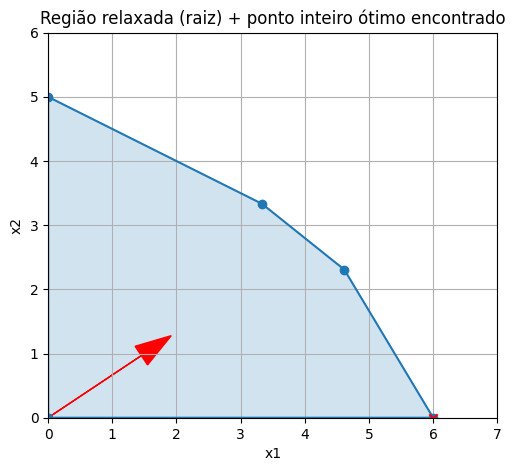

In [ ]:

A0, b0 = augment_constraints_with_bounds(A,b, base_bounds)
if x_inc is not None:
    plot_feasible_with_optimum(A0, b0, c, "Região relaxada (raiz) + ponto inteiro ótimo encontrado", x_inc)
else:
    plot_feasible_with_optimum(A0, b0, c, "Região relaxada (raiz) — nenhum inteiro encontrado", None)
